In [1]:
import math
import re

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

In [2]:
data_for_timeline = pd.read_excel('../extracted_data/Clinical_extraction_cleaned.xlsx')

In [3]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import math, re

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.size'] = 14


class Timeline:
    _PALETTE = {
        "combat":  "#0072B2",   # blue
        "injury":  "#D55E00",   # vermillion
        "assault": "#CC79A7",   # purple
        "various": "#009E73",   # bluish green
        "other":   "#999999",   # gray
    }

    def __init__(self, data: pd.DataFrame):
        data = data.copy()

        def _bucket(row):
            # read trauma_type and normalize
            val = row.get("trauma_type")
            if pd.isna(val) or str(val).strip() == "":
                return "other"

            s = str(val).strip().lower()
            return s if s in ("combat", "various", "injury", "assault") else "other"

        data["Trauma_group"] = data.apply(_bucket, axis=1)

        data["__last_tp"] = data["Time_points_plot"].apply(self._last_timepoint)
        df = (
            data.sort_values(["__last_tp", "Study"], ascending=[False, True])
                .reset_index(drop=True)
        )

        self.Study = df["Study"].tolist()
        self.timepoints = df["Time_points_plot"].tolist()
        self.trauma_groups = df["Trauma_group"].tolist()
        self.ylist = range(4, 4 * len(self.Study) + 4, 4)

        self.colors = [self._PALETTE.get(g, self._PALETTE["other"]) for g in self.trauma_groups]

    def _tokens(self, s):
        if s is None or (isinstance(s, float) and np.isnan(s)) or (isinstance(s, pd.Series) and s.isna().all()):
            return []
        s = str(s).strip()
        if not s:
            return []
        return [t.strip() for t in s.split(",") if t.strip() and t.strip().lower() != "nan"]

    def _parse(self, token: str):
        if ":" in token:
            a, b = token.split(":", 1)
            try:
                a, b = float(a), float(b)
            except ValueError:
                return None
            if b < a:
                a, b = b, a
            return ("range", a, b)
        else:
            try:
                return ("point", float(token))
            except ValueError:
                return None

    def _last_timepoint(self, timepoints):
        parsed = [p for t in self._tokens(timepoints) if (p := self._parse(t)) is not None]
        xs = []
        for kind, *vals in parsed:
            xs.extend(vals)
        return max(xs) if xs else float("-inf")

    def plot_line(self, Study, timepoints, y, color):
        parsed = [p for t in self._tokens(timepoints) if (p := self._parse(t)) is not None]

        xs = []
        for kind, *vals in parsed:
            xs.extend(vals)

        if xs:
            plt.plot([min(xs), max(xs)], [y, y], "-", linewidth=1,
                     solid_capstyle="round", color=color)

        pts = []
        for kind, *vals in parsed:
            if kind == "range":
                a, b = vals
                plt.plot([a, b], [y, y], "-", linewidth=6,
                         solid_capstyle="round", color=color, alpha=0.5)
            else:
                pts.append(vals[0])

        if pts:
            plt.scatter(pts, [y] * len(pts), color=color, zorder=3)

    def set_yticks(self):
        plt.yticks(self.ylist, self.Study)

    def _make_legend(self, ax):
        present = set(self.trauma_groups)
        present_groups = [g for g in self._PALETTE if g in present and g != "other"]
        if "other" in present:
            present_groups.append("other")

        handles = [
            Line2D([0], [0], color=self._PALETTE[g], lw=6, alpha=0.8,
                   label=g.capitalize() if g != "other" else "Other")
            for g in present_groups
        ]
        ax.legend(
            handles=handles, title="Trauma Type", frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.9),
            bbox_transform=ax.transAxes
        )

    def show(self):
        plt.figure(figsize=(10, 30))
        for study, tp, y, color in zip(self.Study, self.timepoints, self.ylist, self.colors):
            self.plot_line(study, tp, y, color)
        self.set_yticks()
        plt.axvline(x=0, color="black", linestyle="-")
        plt.title("Measurement Points of Included Studies")
        plt.xlabel("Time since Trauma (Months)")
        plt.tight_layout()
        ax = plt.gca()
        ax.margins(y=0.01)
        ax.margins(x=0.05)
        self._make_legend(ax)
        plt.show()

    def _plot_one_panel(self, ax, start_idx, end_idx, row_step: int = 4):
        sub_Study = self.Study[start_idx:end_idx]
        sub_timepoints = self.timepoints[start_idx:end_idx]
        sub_colors = self.colors[start_idx:end_idx]
        ylist = range(row_step, row_step * len(sub_Study) + row_step, row_step)
    
        for study, tp, y, color in zip(sub_Study, sub_timepoints, ylist, sub_colors):
            plt.sca(ax)
            self.plot_line(study, tp, y, color)
    
        ax.set_yticks(list(ylist))
        ax.set_yticklabels(sub_Study)
    
        # 🔹 y-axis text (bigger + bold)
        ax.tick_params(axis="y", labelsize=11)
    
        ax.axvline(x=0, color="black", linestyle="-")
        ax.margins(y=0.02, x=0.20)
    
        # 🔹 x-axis text
        ax.tick_params(axis="x", labelsize=11)

    def show_split(
        self,
        ncols: int = 2,
        max_per_panel: int = 18,
        a4_landscape_inches=(11.69, 8.27),
        sharex: bool = True,
        xlabel: str = "Time since Treatment Start (Months)",
        show: bool = True,
        savepath: str | None = None,
        dpi: int = 300,
        num_panels: int | None = None,
        reverse_panels: bool = False,
        panel_wspace: float = 0.30,
        panel_hspace: float = 0.22,
        left: float = 0.06,
        right_margin: float = 0.92,
        top: float = 0.92,
        bottom: float = 0.10,
        row_step: int = 4,
        xlim: tuple[float, float] | None = None,
        x_pad: float = 0.08,
    ):
        total = len(self.Study)

        if num_panels is not None:
            panels = max(1, int(num_panels))
            index_chunks = np.array_split(np.arange(total), panels)
            ncols_eff = min(ncols, panels)
            nrows = math.ceil(panels / ncols_eff)
        else:
            panels = math.ceil(total / max_per_panel) if max_per_panel > 0 else 1
            ncols_eff = min(ncols, panels)
            nrows = math.ceil(panels / ncols_eff)
            index_chunks = [
                np.arange(p * max_per_panel, min((p + 1) * max_per_panel, total))
                for p in range(panels)
            ]

        if xlim is None:
            xs = []
            for tps in self.timepoints:
                for tok in self._tokens(tps):
                    p = self._parse(tok)
                    if p is None:
                        continue
                    _, *vals = p
                    xs.extend(vals)
            if xs:
                xmin, xmax = min(xs), max(xs)
                span = xmax - xmin if xmax > xmin else 1.0
                xmin -= span * x_pad
                xmax += span * x_pad
            else:
                xmin, xmax = -1.0, 1.0
        else:
            xmin, xmax = xlim

        fig = plt.figure(figsize=a4_landscape_inches, constrained_layout=False)
        gs = GridSpec(
            nrows=nrows, ncols=ncols_eff, figure=fig,
            left=left, right=right_margin, top=top, bottom=bottom,
            wspace=panel_wspace, hspace=panel_hspace
        )

        axes = []
        for p, idxs in enumerate(index_chunks):
            r, c = divmod(p, ncols_eff)
            if reverse_panels:
                c = ncols_eff - 1 - c

            ax = fig.add_subplot(gs[r, c], sharex=axes[0] if (sharex and axes) else None)
            axes.append(ax)

            start, end = (int(idxs.min()), int(idxs.max()) + 1) if len(idxs) else (0, 0)
            self._plot_one_panel(ax, start, end, row_step=row_step)
            ax.set_xlim(xmin, xmax)

            if r < nrows - 1:
                plt.setp(ax.get_xticklabels(), visible=False)
                ax.set_xlabel("")
            else:
                ax.set_xlabel(xlabel)

            if end - start == 0:
                ax.set_visible(False)

        present = set(self.trauma_groups)
        present_groups = [g for g in self._PALETTE if g in present and g != "other"]
        if "other" in present:
            present_groups.append("other")

        handles = [
            Line2D([0], [0], color=self._PALETTE[g], lw=6, alpha=0.8,
                   label=g.capitalize() if g != "other" else "Other")
            for g in present_groups
        ]

        leg_ax = fig.add_axes([right_margin + 0.005, 0.15, 1 - right_margin - 0.03, 0.7])
        leg_ax.axis("off")
        leg_ax.legend(handles=handles, title="Trauma Type", frameon=False, loc="center left")

        if savepath:
            fig.savefig(savepath, dpi=dpi, bbox_inches="tight")
        if show:
            plt.show()
        plt.close(fig)

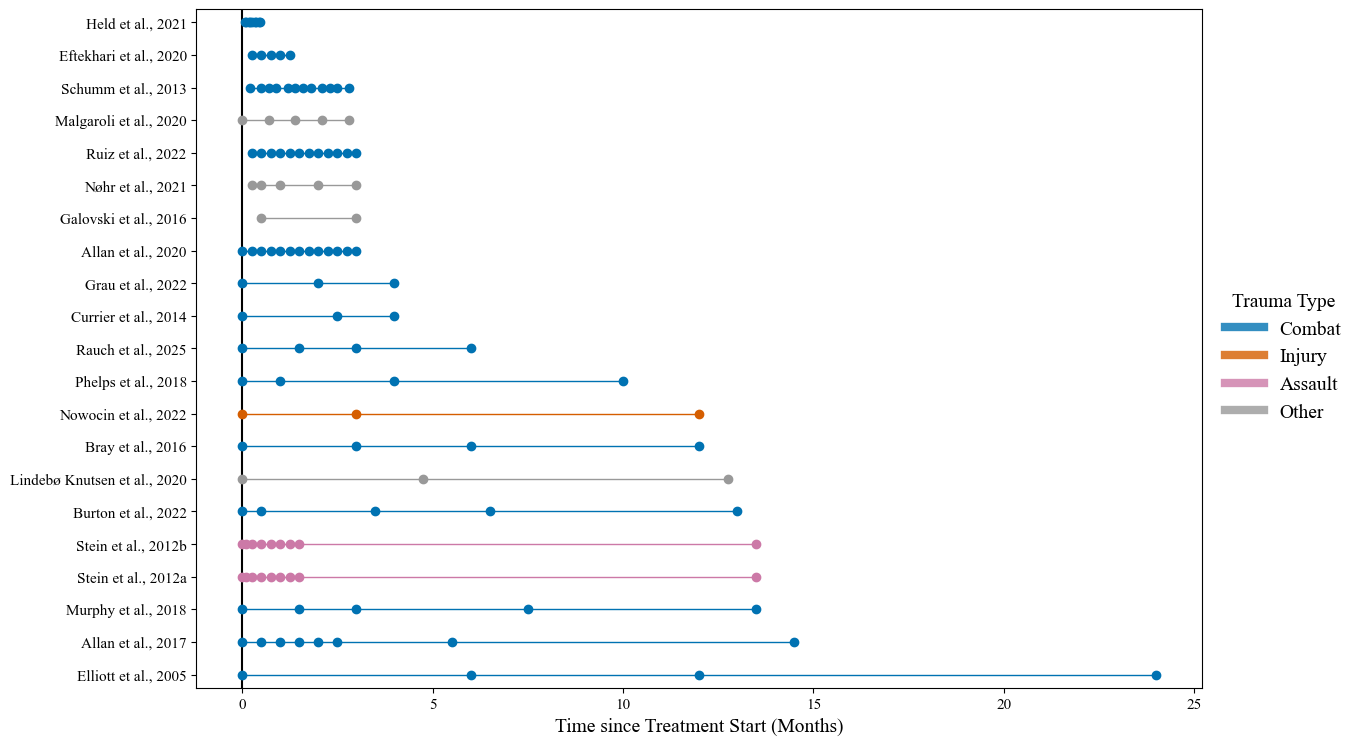

In [4]:
tl = Timeline(data_for_timeline)
tl._plot_one_panel
tl.show_split(num_panels=1, ncols=2, reverse_panels = True, savepath="timeline_panels.png", panel_wspace=0.5, row_step=10, x_pad=0.05)